<a href="https://colab.research.google.com/github/JillFang1030/Fang_project/blob/main/fNIRS_behavioral_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thesis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import plotly.express as px

# 1. load data
df_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
df_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

# 2. Label
df_dd['Group'] = 'DD'
df_td['Group'] = 'TD'

# 3. Merge
df_project = pd.concat([df_dd, df_td], ignore_index=True)

# 4. Print the names of the columns
print("合併後的欄位有：\n", df_project.columns.tolist())

合併後的欄位有：
 ['ID', 'C_MC', 'C_CTOPP', 'C_RAN', 'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF', 'RF_inc_w/o skip', 'RF_inc_w/ skip', 'Character_recog (raw score)', 'Character_recog (PR)', "IQ_Raven's (raw)", "IQ_Raven's (Standard)", 'fNIRS_Date1', 'Chinese_MAPA', 'Story_Listening', 'Chinese_Priming', 'Chinese_semantic', 'Resting', 'Chinese_RAN', 'fNIRS_Date2', 'Chinese_MAPA.1', 'Story_Listening.1', 'Chinese_Priming.1', 'Chinese_semantic.1', 'Resting.1', 'Chinese_RAN.1', 'Group', 'C_PIC(52)', 'RF_inc_w/o_skip', 'RF_inc_w/_skip', 'Chinese_Semantic']


# Brain-Behavior Correlation

Here, I use pre-processed beta value and try to find if there's any brain-behavior correlation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

folder_path = '/content/drive/MyDrive/Colab Notebooks/'

try:
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    print("✅ 所有檔案（CSV 與 Excel）讀取成功")
except Exception as e:
    print(f"❌ 讀取失敗：{e}")
    raise

✅ 所有檔案（CSV 與 Excel）讀取成功


In [ ]:
for df in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
    df.columns = df.columns.str.strip()
beta_all = pd.concat([df_beta_dd, df_beta_td], ignore_index=True)
target_channels = [6, 16, 21]
beta_filtered = beta_all[(beta_all['Channel'].isin(target_channels)) & (beta_all['cond'] == 'MA')]
beta_pivot = beta_filtered.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot.columns = ['ID', 'Beta_CH6', 'Beta_CH16', 'Beta_CH21']

In [ ]:
behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)
behavior_subset = behavior_all[['ID', 'C_MC', 'Character_recog (PR)']].copy()
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.stats.multitest as smm

behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]
select_columns = ['ID'] + list(target_behaviors)
behavior_subset = behavior_all[['ID'] + target_behaviors].copy()
beta_pivot['ID'] = beta_pivot['ID'].astype(int)
behavior_subset['ID'] = behavior_subset['ID'].astype(int)
final_df = pd.merge(beta_pivot, behavior_subset, on='ID', how='inner')

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.stats.multitest as smm
from scipy.stats import pearsonr

def run_correlation_with_fdr(df, channels, behaviors):
    results = []
    raw_p_values = [] # 用來存取所有的原始 p 值

    # 引入 github 建立好的核心統計模組
    from utils.correlation import calculate_group_correlations
    all_ids = df['ID'].unique()

    # 🔥 核心修正 1：外層迴圈走通道，內層迴圈走行為指標
    for ch in channels:
        for bh in behaviors:

            # 🔥 核心修正 2：在迴圈肚子裡，精確把「當前這一個行為 bh」丟進 utils 算！
            raw_stats = calculate_group_correlations(df, [ch], bh, all_ids, all_ids)

            r_val = np.nan
            p_val = np.nan

            # 🔥 核心修正 3：精確對齊當前通道 ch 的數值
            if ch in raw_stats and raw_stats[ch]['all_r'] is not None:
                r_val = raw_stats[ch]['all_r']
                p_val = raw_stats[ch]['all_p']

            results.append({
                'Channel': ch,
                'Behavior': bh,
                'Pearson_r': round(r_val, 3) if (r_val is not None and not np.isnan(r_val)) else np.nan,
                'p_value_raw': round(p_val, 4) if (p_val is not None and not np.isnan(p_val)) else np.nan
            })
            raw_p_values.append(1.0 if (p_val is None or np.isnan(p_val)) else p_val)

    # 27 次比較的 FDR 校正
    reject, p_corrected, _, _ = smm.multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

    # 將校正結果存回表格
    for idx, res in enumerate(results):
        res['p_value_FDR_corrected'] = round(p_corrected[idx], 4)
        res['Significant_After_FDR'] = '★ TRUE' if reject[idx] else ''
        p_raw = res['p_value_raw']
        res['Significant_Raw'] = '*' if (p_raw is not None and p_raw < 0.05) else ''

    return pd.DataFrame(results)


# ==========================================
# 執行分析：計算整體的 27 行總表
# ==========================================
target_channels_short = ['Beta_CH6', 'Beta_CH16', 'Beta_CH21']

print("========== 全體兒童（N=30）27次相關分析結果 ==========")
analysis_results_all = run_correlation_with_fdr(final_df, target_channels_short, target_behaviors)
print(analysis_results_all.to_string(index=False))
analysis_results_all.to_excel('All_subjects_3ch_9behav_results.xlsx', index=False)

print("\n" + "="*80 + "\n")

========== 全體兒童（N=30）27次相關分析結果 ==========
  Channel             Behavior  Pearson_r  p_value_raw  p_value_FDR_corrected Significant_After_FDR Significant_Raw
 Beta_CH6                 C_MC      0.045       0.7345                 0.9711                                      
 Beta_CH6 Character_recog (PR)     -0.116       0.3764                 0.9711                                      
 Beta_CH6              C_CTOPP      0.017       0.8991                 0.9711                                      
 Beta_CH6                C_RAN     -0.004       0.9782                 0.9782                                      
 Beta_CH6                 C_CR     -0.108       0.4124                 0.9711                                      
 Beta_CH6                 C_WR     -0.040       0.7625                 0.9711                                      
 Beta_CH6                C_PIC     -0.085       0.5163                 0.9711                                      
 Beta_CH6           C_PIC (52)

In [ ]:
# 將全體兒童的 27 行相關分析結果存成 Excel 檔案
excel_filename = 'All_Subjects_60_Correlation_Results.xlsx'

analysis_results_all.to_excel(excel_filename, index=False)

print("\n" + "="*60)
print(f"🎉 全體兒童 Excel 表格已成功導出！")
print(f"📁 檔案名稱：{excel_filename}")
print("說明：點開 Colab 左側的資料夾，就能下載囉！")
print("="*60)


🎉 全體兒童 Excel 表格已成功導出！
📁 檔案名稱：All_Subjects_60_Correlation_Results.xlsx
說明：點開 Colab 左側的資料夾，就能下載囉！


只有CH16的C_PIC (52)有超級微小的顯著

## Back to focus on the 3 channels.

✅ 檔案重讀成功！大資料庫就位。
⏳ 正在計算目標 3通道 ✕ 9指標 的 27 次相關矩陣...
🎉 【目標 3 通道熱圖已成功存檔】：target_3ch_9behav_heatmap.png


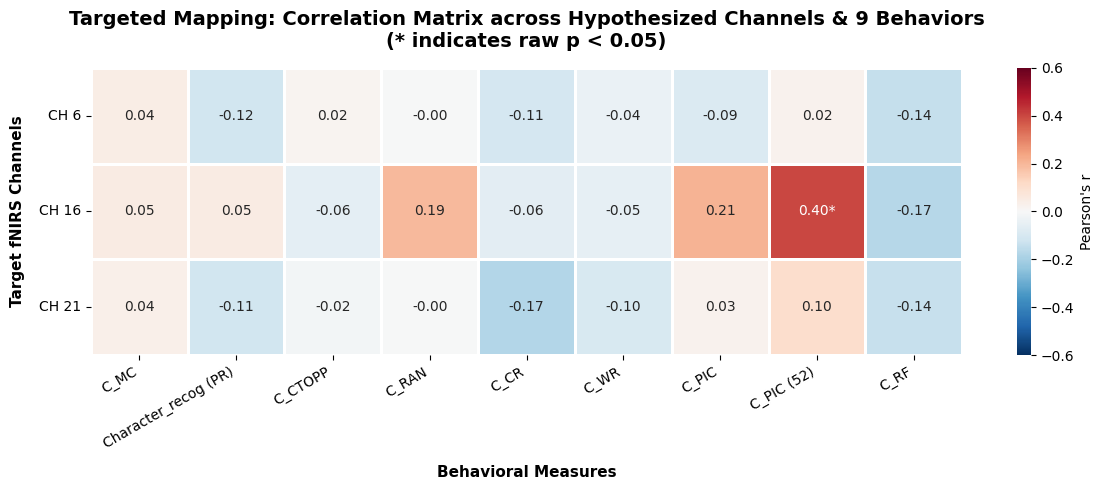

🎉 【27行原始統計總表已自動存檔】：All_Subjects_60_Correlation_Results.xlsx


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt


# 1. 讀取檔案與建立大資料庫
try:
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    for df in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
        df.columns = df.columns.str.strip()

    beta_all = pd.concat([df_beta_dd, df_beta_td], ignore_index=True)
    behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)
    print("✅ 檔案重讀成功！大資料庫就位。")
except Exception as e:
    print(f"❌ 檔案讀取失敗，請確認雲端硬碟路徑：{e}")
    raise


# 鎖定3 個 Channel (CH6, CH16, CH21)
target_channels = [6, 16, 21]

beta_ma_all = beta_all[beta_all['cond'] == 'MA'].copy()
beta_pivot_3ch = beta_ma_all.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot_3ch.rename(columns={'Subject': 'ID'}, inplace=True)
beta_pivot_3ch['ID'] = beta_pivot_3ch['ID'].astype(int)

# 9 個行為指標名單
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]
behavior_subset = behavior_all[['ID'] + target_behaviors].copy()
behavior_subset['ID'] = behavior_subset['ID'].astype(int)

# 合併成3通道的大表
final_df_3ch = pd.merge(beta_pivot_3ch, behavior_subset, on='ID', how='inner')

# 計算 3 通道 ✕ 9 指標 = 27 次相關

print("⏳ 正在計算目標 3通道 ✕ 9指標 的 27 次相關矩陣...")
matrix_r = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)
matrix_annot = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)
results_list_27 = []

for ch in target_channels:
    for bh in target_behaviors:
        if ch in final_df_3ch.columns and bh in final_df_3ch.columns:
            valid_data = final_df_3ch[[ch, bh]].dropna()
            if len(valid_data) > 2:
                r_val, p_val = pearsonr(valid_data[ch], valid_data[bh])
            else:
                r_val, p_val = np.nan, np.nan
        else:
            r_val, p_val = np.nan, np.nan

        matrix_r.loc[f'CH {ch}', bh] = r_val if not np.isnan(r_val) else 0.0

        # 如果原始 p 值 < 0.05，標註星號
        if not np.isnan(p_val) and p_val < 0.05:
            matrix_annot.loc[f'CH {ch}', bh] = f"{r_val:.2f}*"
        else:
            matrix_annot.loc[f'CH {ch}', bh] = f"{r_val:.2f}" # 沒顯著也顯示 r 值，讓圖表資訊更豐富

        results_list_27.append({
            'Channel': f'CH {ch}',
            'Behavior': bh,
            'Pearson_r': round(r_val, 3) if not np.isnan(r_val) else np.nan,
            'p_value_raw': round(p_val, 4) if not np.isnan(p_val) else np.nan
        })


# 呼叫新寫好的單張熱圖模組
from utils.plots import plot_single_target_heatmap
plot_single_target_heatmap(matrix_r, matrix_annot)

# 存新檔
plt.savefig('target_3ch_9behav_heatmap.png', dpi=300, bbox_inches='tight')
print("🎉 【目標 3 通道熱圖已成功存檔】：target_3ch_9behav_heatmap.png")

plt.show()

# 儲存 27 行總表成 Excel
df_results_27 = pd.DataFrame(results_list_27)
df_results_27.to_excel('All_Subjects_60_Correlation_Results.xlsx', index=False)
print("🎉 【27行原始統計總表已自動存檔】：All_Subjects_60_Correlation_Results.xlsx")

Since there's no clear pattern overall, I separate the two groups and try to see the correlation.

正在整合原始大腦 Beta 數據變數 (每組基準 N = 30)...
開始進行組間 (Between-group) 迴歸線斜率差異檢定...

==================== 💡 【組間 (Between-group)】斜率差異檢定總表 ====================


,ROI_Channel,Behavioral_Measure,TD_N,DD_N,TD_Group_r,DD_Group_r,Between_Group_Z,Between_Group_p,Slope_Significantly_Different
0,Beta_CH6,C_MC,30,30,-0.064,0.346,-1.564,0.11779,No
1,Beta_CH6,Character_recog (PR),30,30,-0.214,0.366,-2.210,0.02711,★ TRUE
2,Beta_CH6,C_CTOPP,30,30,-0.058,0.200,-0.956,0.33903,No
3,Beta_CH6,C_RAN,30,30,-0.102,-0.017,-0.310,0.75645,No
4,Beta_CH6,C_CR,30,30,-0.059,0.225,-1.056,0.29108,No
5,Beta_CH6,C_WR,30,30,-0.040,0.239,-1.042,0.29738,No
6,Beta_CH6,C_PIC,30,30,-0.129,0.171,-1.112,0.26603,No
7,Beta_CH6,C_RF,30,27,-0.045,0.066,-0.398,0.69063,No
8,Beta_CH16,C_MC,30,30,-0.319,0.125,-1.674,0.09415,No
9,Beta_CH16,Character_recog (PR),30,30,-0.201,0.037,-0.884,0.37649,No



💾 統計結果已成功存檔為 Excel 檔案：'Between_Group_Slope_Comparison_Results.xlsx'
🎨 組間交互作用熱圖視覺化完成！已儲存為圖檔：'between_group_interaction_heatmap.png'


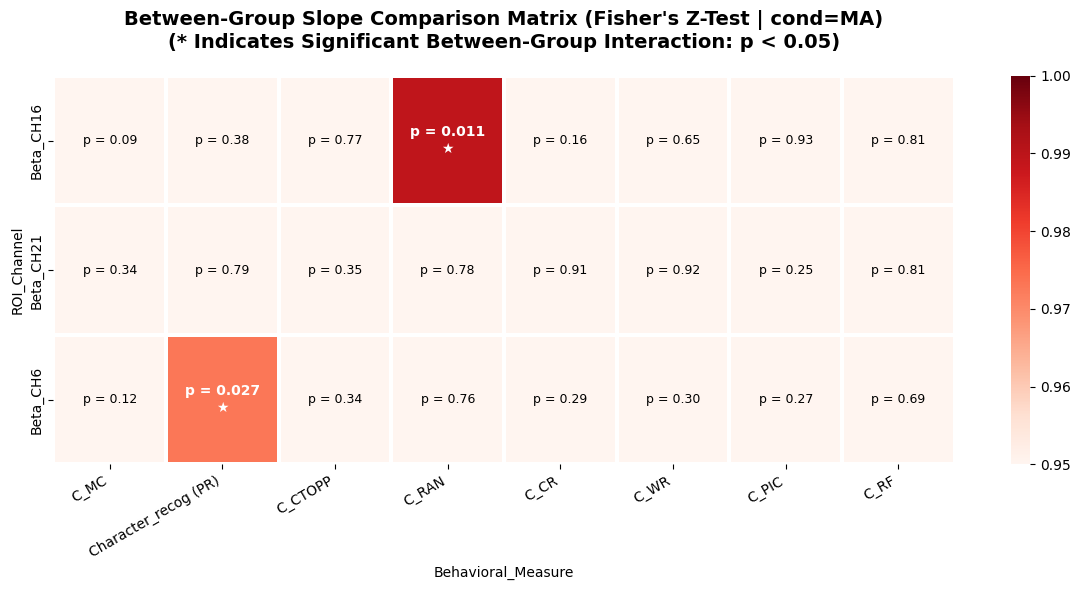

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 💾 1. 直接沿用妳記憶體中已讀取的 df_beta_td 與 df_beta_dd，徹底繞過路徑地雷
# =========================================================================
print("正在整合原始大腦 Beta 數據變數 (每組基準 N = 30)...")

# 確保乾淨複製，避免影響到妳之前的 dataframe
td_temp = df_beta_td.copy()
dd_temp = df_beta_dd.copy()

# 欄位去空格確保格式一致
for temp_df in [td_temp, dd_temp]:
    temp_df.columns = temp_df.columns.str.strip()

# 合併兩組數據成單一長表
brain_df = pd.concat([td_temp, dd_temp], ignore_index=True)

# 篩選 cond == 'MA' 實驗情境
target_cond = 'MA'
brain_df = brain_df[brain_df['cond'] == target_cond]

# 定義要分析的 3 個感興趣通道與 9 個行為指標
target_channels = [6, 16, 21]
behaviors = ['C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN', 'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF']

between_group_results = []

# =========================================================================
# 🛠️ 2. 核心組間分析管線 (Between-group Fisher's Z Test)
# =========================================================================
print("開始進行組間 (Between-group) 迴歸線斜率差異檢定...")

for ch in target_channels:
    # 篩選特定通道的大腦資料
    ch_df = brain_df[brain_df['Channel'] == ch]

    for bh in behaviors:
        # 安全防呆：確保您的行為總表 final_df 裡有該行為欄位
        if bh not in final_df.columns:
            continue

        # 精確透過 'ID' (對齊妳 final_df 的受試者欄位名稱) 串接大腦與行為分數
        # 💡 注意：妳長表裡的受試者欄位是 'Subject'，我們在這裡將其與 final_df 的 'ID' 對齊
        merged_df = pd.merge(final_df[['ID', bh]], ch_df[['Subject', 'Group', 'Beta']], left_on='ID', right_on='Subject', how='inner')

        # 依據 Group 標籤拆分組別，並自動排除行為或大腦有缺失值 (NaN) 的個案
        td_data = merged_df[merged_df['Group'] == 'TD'].dropna(subset=[bh, 'Beta'])
        dd_data = merged_df[merged_df['Group'] == 'DD'].dropna(subset=[bh, 'Beta'])

        # 獲取各組實際參與該項分析的有效樣本數 (精確扣除缺失值，TD=30, DD=30)
        n_td = len(td_data)
        n_dd = len(dd_data)

        # Fisher's Z 檢定要求有效樣本數必須大於 3
        if n_td <= 3 or n_dd <= 3:
            continue

        # 計算兩組各自真實的組內 Pearson 相關係數 r
        r_td, _ = stats.pearsonr(td_data[bh], td_data['Beta'])
        r_dd, _ = stats.pearsonr(dd_data[bh], dd_data['Beta'])

        # --- Fisher's r-to-z 轉換與組間差異檢定 ---
        z_td = np.arctanh(np.clip(r_td, -0.9999, 0.9999))
        z_dd = np.arctanh(np.clip(r_dd, -0.9999, 0.9999))

        # 計算組間標準誤差
        se_diff = np.sqrt(1 / (n_td - 3) + 1 / (n_dd - 3))

        # 計算組間 Z 檢定統計量與雙尾 p-value
        z_stat = (z_td - z_dd) / se_diff
        p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))

        between_group_results.append({
            'ROI_Channel': f"Beta_CH{ch}",
            'Behavioral_Measure': bh,
            'TD_N': n_td,
            'DD_N': n_dd,
            'TD_Group_r': round(r_td, 3),
            'DD_Group_r': round(r_dd, 3),
            'Between_Group_Z': round(z_stat, 3),
            'Between_Group_p': round(p_val, 5),
            'Slope_Significantly_Different': '★ TRUE' if p_val < 0.05 else 'No'
        })

# 轉換為統計結果長表
df_between_group = pd.DataFrame(between_group_results)

print("\n==================== 💡 【組間 (Between-group)】斜率差異檢定總表 ====================")
display(df_between_group)

# 儲存為實體 Excel 表格
excel_output_name = 'Between_Group_Slope_Comparison_Results.xlsx'
df_between_group.to_excel(excel_output_name, index=False)
print(f"\n💾 統計結果已成功存檔為 Excel 檔案：'{excel_output_name}'")

# =========================================================================
# 🎨 3. 繪製並存檔全新的「組間交互作用顯著差異熱圖」
# =========================================================================
if not df_between_group.empty:
    p_matrix = df_between_group.pivot(index='ROI_Channel', columns='Behavioral_Measure', values='Between_Group_p')
    available_behaviors = [b for b in behaviors if b in p_matrix.columns]
    p_matrix = p_matrix[available_behaviors]

    plt.figure(figsize=(12, 6))
    plot_data = 1 - p_matrix  # 數值越接近 1 代表 p 值越小 (越顯著)

    ax = sns.heatmap(plot_data, cmap='Reds', vmin=0.95, vmax=1.0, cbar=True, linewidths=1.5, linecolor='white')

    for i in range(p_matrix.shape[0]):
        for j in range(p_matrix.shape[1]):
            p_val = p_matrix.iloc[i, j]
            if p_val < 0.05:
                text_label = f"p = {p_val:.3f}\n★"
                ax.text(j + 0.5, i + 0.5, text_label, ha='center', va='center', color='white', fontweight='bold', fontsize=10)
            else:
                text_label = f"p = {p_val:.2f}"
                ax.text(j + 0.5, i + 0.5, text_label, ha='center', va='center', color='black', fontsize=9)

    plt.title(f"Between-Group Slope Comparison Matrix (Fisher's Z-Test | cond={target_cond})\n(* Indicates Significant Between-Group Interaction: p < 0.05)", fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()

    output_img_name = 'between_group_interaction_heatmap.png'
    plt.savefig(output_img_name, dpi=300, bbox_inches='tight')
    print(f"🎨 組間交互作用熱圖視覺化完成！已儲存為圖檔：'{output_img_name}'")
    plt.show()